# 🛍️ Mall Customer Segmentation
## Clustering Analysis with K-Means

**Author :** Handahamé DIA

**Date :** May 2026

**Tool :** Python (Pandas, Scikit-learn, Seaborn)

**Dataset :** Mall Customer Segmentation Dataset

---

## 📌 Objective
Segment mall customers into distinct groups based on their spending behavior and annual income to help the marketing team personalize their offers and maximize revenue.

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("Blues_d")

print("Libraries imported successfully !")

Libraries imported successfully !


In [6]:
# Upload the dataset
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [7]:
# Load the dataset
customers = pd.read_csv('Mall_Customers.csv')

# First look
print("Shape :", customers.shape)
print("\nColumns :\n", customers.columns.tolist())
print("\nFirst 5 rows :")
customers.head()

Shape : (200, 5)

Columns :
 ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows :


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
# General information
print("Dataset Info :")
customers.info()
print("\nDescriptive Statistics :")
customers.describe()

Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Descriptive Statistics :


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
# Missing values and duplicates
print("Missing values :")
print(customers.isnull().sum())
print("\nDuplicate rows :", customers.duplicated().sum())

Missing values :
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows : 0


## 🔍 Exploratory Data Analysis
### Univariate Analysis

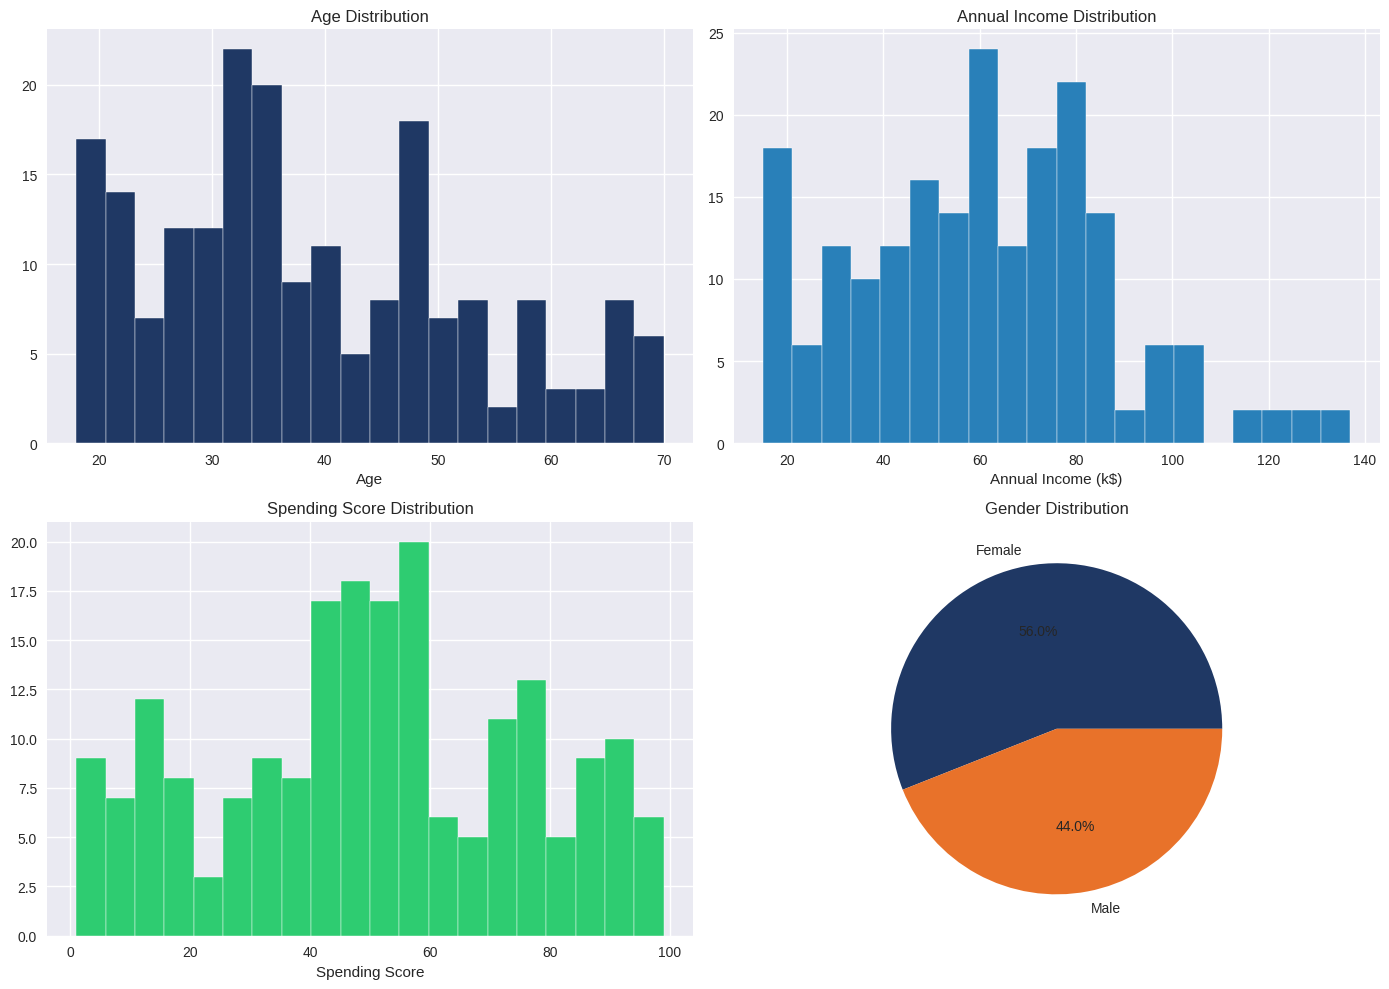

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
axes[0,0].hist(customers['Age'], bins=20,
               color='#1F3864', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

# Income
axes[0,1].hist(customers['Annual Income (k$)'],
               bins=20, color='#2980B9',
               edgecolor='white')
axes[0,1].set_title('Annual Income Distribution')
axes[0,1].set_xlabel('Annual Income (k$)')

# Spending Score
axes[1,0].hist(customers['Spending Score (1-100)'],
               bins=20, color='#2ECC71',
               edgecolor='white')
axes[1,0].set_title('Spending Score Distribution')
axes[1,0].set_xlabel('Spending Score')

# Gender
gender_counts = customers['Gender'].value_counts()
axes[1,1].pie(gender_counts,
              labels=gender_counts.index,
              autopct='%1.1f%%',
              colors=['#1F3864', '#E8722A'])
axes[1,1].set_title('Gender Distribution')

plt.tight_layout()
plt.savefig('univariate_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Bivariate Analysis

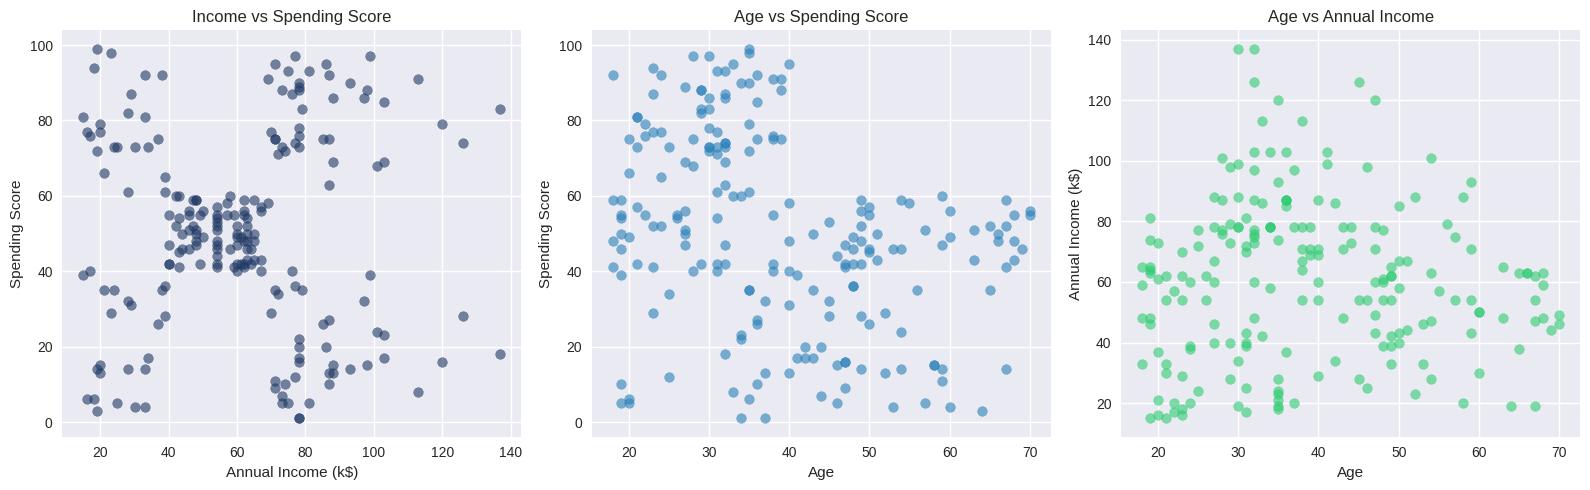

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Income vs Spending Score
axes[0].scatter(customers['Annual Income (k$)'],
                customers['Spending Score (1-100)'],
                color='#1F3864', alpha=0.6)
axes[0].set_title('Income vs Spending Score')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')

# Age vs Spending Score
axes[1].scatter(customers['Age'],
                customers['Spending Score (1-100)'],
                color='#2980B9', alpha=0.6)
axes[1].set_title('Age vs Spending Score')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score')

# Age vs Income
axes[2].scatter(customers['Age'],
                customers['Annual Income (k$)'],
                color='#2ECC71', alpha=0.6)
axes[2].set_title('Age vs Annual Income')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')

plt.tight_layout()
plt.savefig('bivariate_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

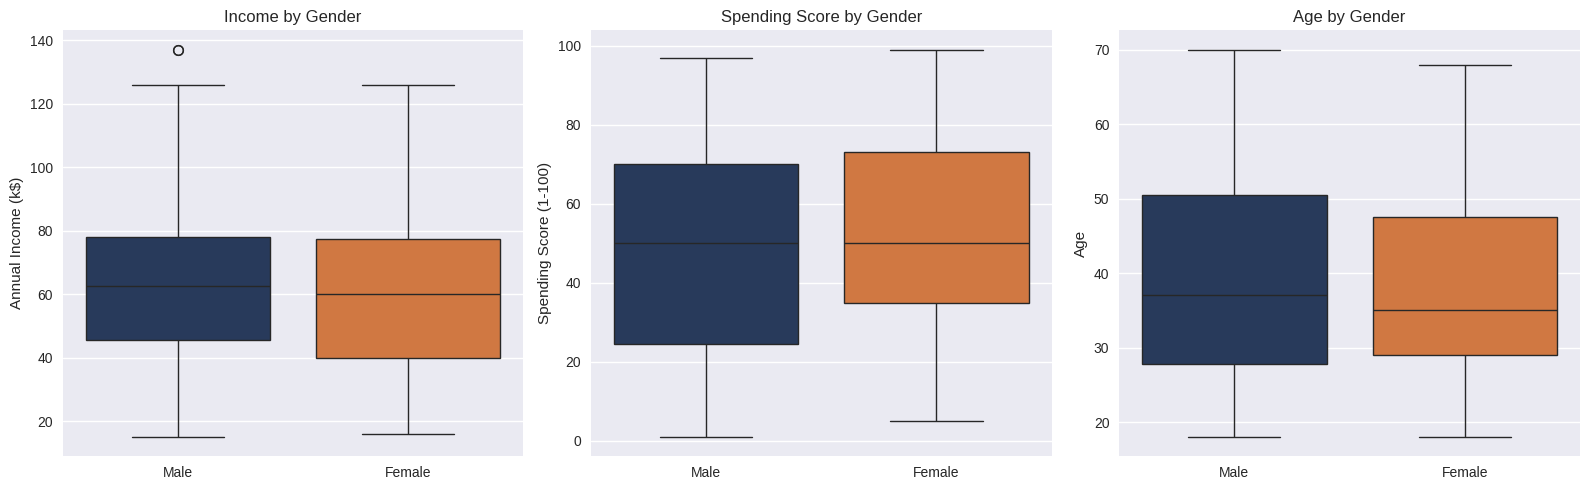

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Income by Gender
sns.boxplot(data=customers,
            x='Gender', y='Annual Income (k$)',
            hue='Gender', palette=['#1F3864', '#E8722A'],
            legend=False, ax=axes[0])
axes[0].set_title('Income by Gender')
axes[0].set_xlabel('')

# Spending Score by Gender
sns.boxplot(data=customers,
            x='Gender', y='Spending Score (1-100)',
            hue='Gender', palette=['#1F3864', '#E8722A'],
            legend=False, ax=axes[1])
axes[1].set_title('Spending Score by Gender')
axes[1].set_xlabel('')

# Age by Gender
sns.boxplot(data=customers,
            x='Gender', y='Age',
            hue='Gender', palette=['#1F3864', '#E8722A'],
            legend=False, ax=axes[2])
axes[2].set_title('Age by Gender')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('boxplots_gender.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 🔢 K-Means Clustering

### Step 1 - Finding the Optimal Number of Clusters
#### Elbow Method :

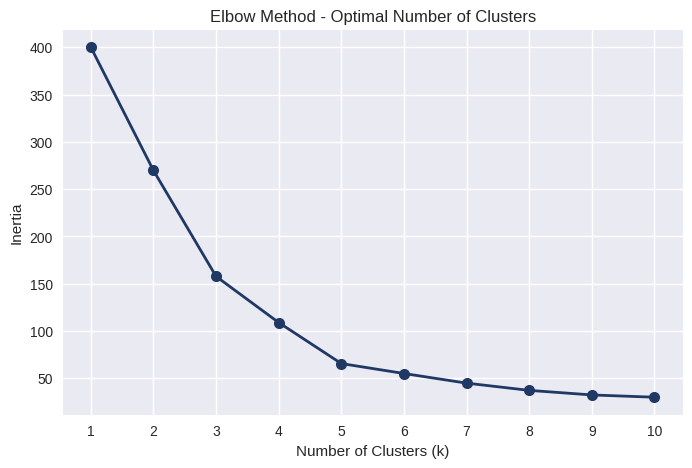

In [13]:
# Select features for clustering
X = customers[['Annual Income (k$)',
               'Spending Score (1-100)']]

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia,
         marker='o', color='#1F3864',
         linewidth=2, markersize=8)
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.savefig('elbow_method.png',
            dpi=150, bbox_inches='tight')
plt.show()

#### Silhouette Score - Confirming k=5

k=2 → Silhouette Score : 0.321
k=3 → Silhouette Score : 0.467
k=4 → Silhouette Score : 0.494
k=5 → Silhouette Score : 0.555
k=6 → Silhouette Score : 0.540
k=7 → Silhouette Score : 0.528
k=8 → Silhouette Score : 0.455
k=9 → Silhouette Score : 0.457
k=10 → Silhouette Score : 0.443


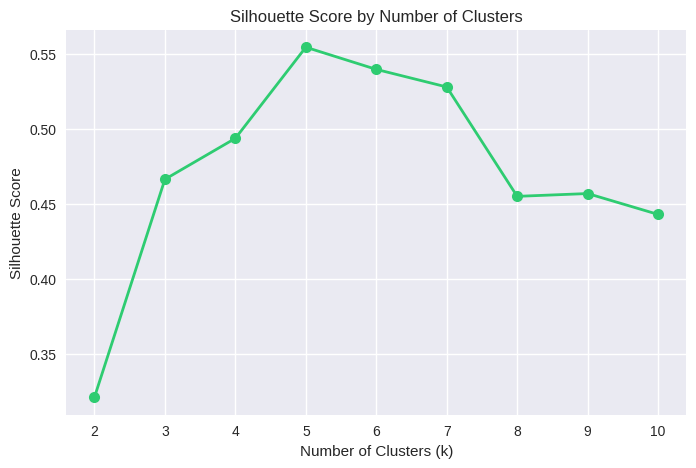

In [14]:
# Silhouette score to confirm optimal k
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k} → Silhouette Score : {score:.3f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores,
         marker='o', color='#2ECC71',
         linewidth=2, markersize=8)
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.savefig('silhouette_score.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Step 2 - Training K-Means with k=5


In [15]:
# Train K-Means with k=5
kmeans = KMeans(n_clusters=5,
                random_state=42,
                n_init=10)

customers['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster distribution :")
print(customers['Cluster'].value_counts()
      .sort_index())

Cluster distribution :
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


### Step 3 - Visualizing the Clusters

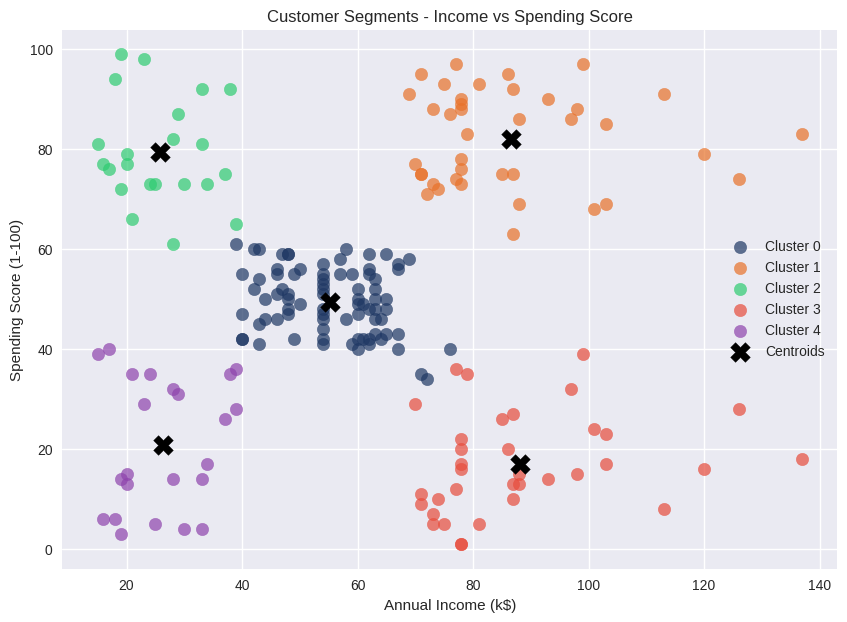

In [16]:
colors = ['#1F3864', '#E8722A', '#2ECC71',
          '#E74C3C', '#8E44AD']

plt.figure(figsize=(10, 7))

for i in range(5):
    cluster_data = customers[customers['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                color=colors[i], label=f'Cluster {i}',
                alpha=0.7, s=80)

# Plot centroids
centroids = scaler.inverse_transform(
    kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            color='black', marker='X',
            s=200, label='Centroids', zorder=5)

plt.title('Customer Segments - Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.savefig('clusters_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Step 4 - Cluster Profiling

In [17]:
# Profile each cluster
profile = customers.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(1)

print("Cluster Profiles :")
print(profile.to_string())

Cluster Profiles :
         Count  Avg_Age  Avg_Income  Avg_Spending
Cluster                                          
0           81     42.7        55.3          49.5
1           39     32.7        86.5          82.1
2           22     25.3        25.7          79.4
3           35     41.1        88.2          17.1
4           23     45.2        26.3          20.9


In [18]:
# Name the clusters
cluster_names = {
    0: 'Average Customers',
    1: 'High Value Customers',
    2: 'Young Impulsive Customers',
    3: 'Careful High Earners',
    4: 'Budget Conscious Customers'
}

customers['Cluster Name'] = customers[
    'Cluster'].map(cluster_names)

print("Cluster distribution :")
print(customers['Cluster Name']
      .value_counts())

Cluster distribution :
Cluster Name
Average Customers             81
High Value Customers          39
Careful High Earners          35
Budget Conscious Customers    23
Young Impulsive Customers     22
Name: count, dtype: int64


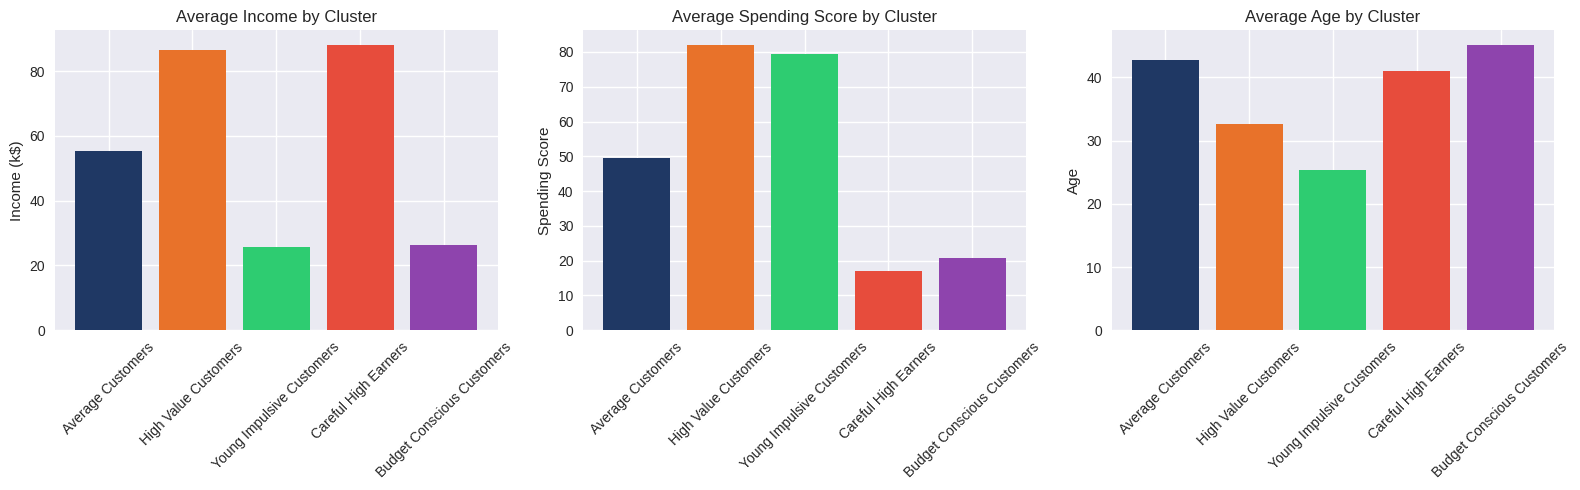

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#1F3864', '#E8722A', '#2ECC71',
          '#E74C3C', '#8E44AD']

names = [cluster_names[i] for i in range(5)]

# Average Income by Cluster
axes[0].bar(names, profile['Avg_Income'],
            color=colors)
axes[0].set_title('Average Income by Cluster')
axes[0].set_ylabel('Income (k$)')
axes[0].tick_params(axis='x', rotation=45)

# Average Spending by Cluster
axes[1].bar(names, profile['Avg_Spending'],
            color=colors)
axes[1].set_title('Average Spending Score by Cluster')
axes[1].set_ylabel('Spending Score')
axes[1].tick_params(axis='x', rotation=45)

# Average Age by Cluster
axes[2].bar(names, profile['Avg_Age'],
            color=colors)
axes[2].set_title('Average Age by Cluster')
axes[2].set_ylabel('Age')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('cluster_profiles.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 🌳 Hierarchical Clustering (CAH)

### Step 1 - Dendrogram

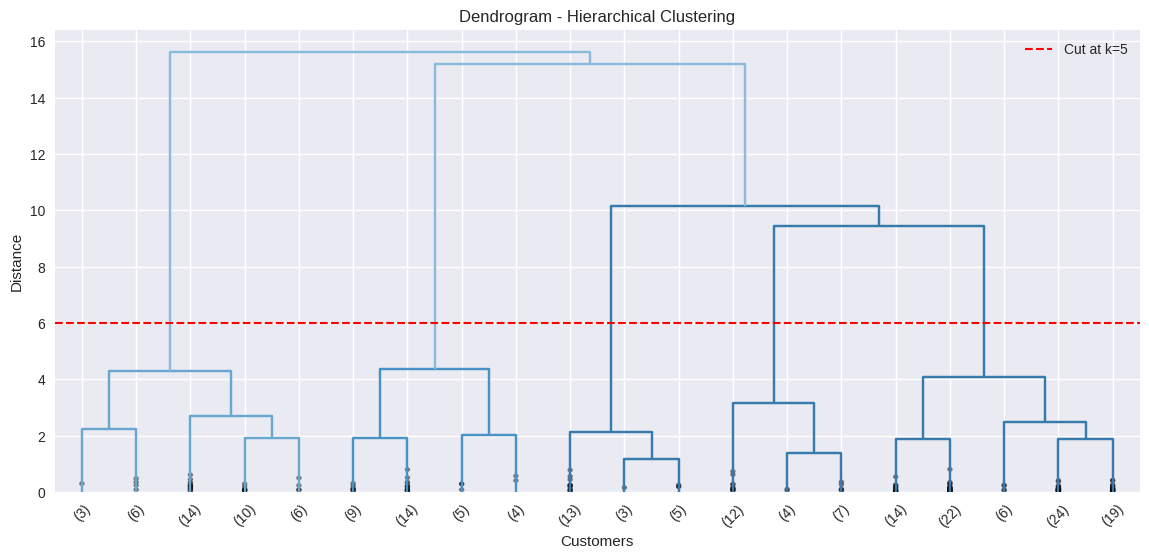

In [29]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute linkage matrix
linked = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 6))
dendrogram(linked,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True)
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.axhline(y=6, color='red',
            linestyle='--', linewidth=1.5,
            label='Cut at k=5')
plt.legend()
plt.savefig('dendrogram.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Step 2 - Applying CAH with k=5


In [31]:
from sklearn.cluster import AgglomerativeClustering

# Apply CAH with k=5
cah = AgglomerativeClustering(n_clusters=5,
                               linkage='ward')
customers['Cluster_CAH'] = cah.fit_predict(X_scaled)

# Profile CAH clusters
profile_cah = customers.groupby('Cluster_CAH').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(1)

print("CAH Cluster Profiles :")
print(profile_cah.to_string())

# Quick comparison
print("\nK-Means vs CAH - Size comparison :")
print("K-Means :", sorted(customers['Cluster']
      .value_counts().tolist(), reverse=True))
print("CAH     :", sorted(customers['Cluster_CAH']
      .value_counts().tolist(), reverse=True))

CAH Cluster Profiles :
             Count  Avg_Age  Avg_Income  Avg_Spending
Cluster_CAH                                          
0               32     41.0        89.4          15.6
1               39     32.7        86.5          82.1
2               85     42.5        55.8          49.1
3               21     25.3        25.1          80.0
4               23     45.2        26.3          20.9

K-Means vs CAH - Size comparison :
K-Means : [81, 39, 35, 23, 22]
CAH     : [85, 39, 32, 23, 21]


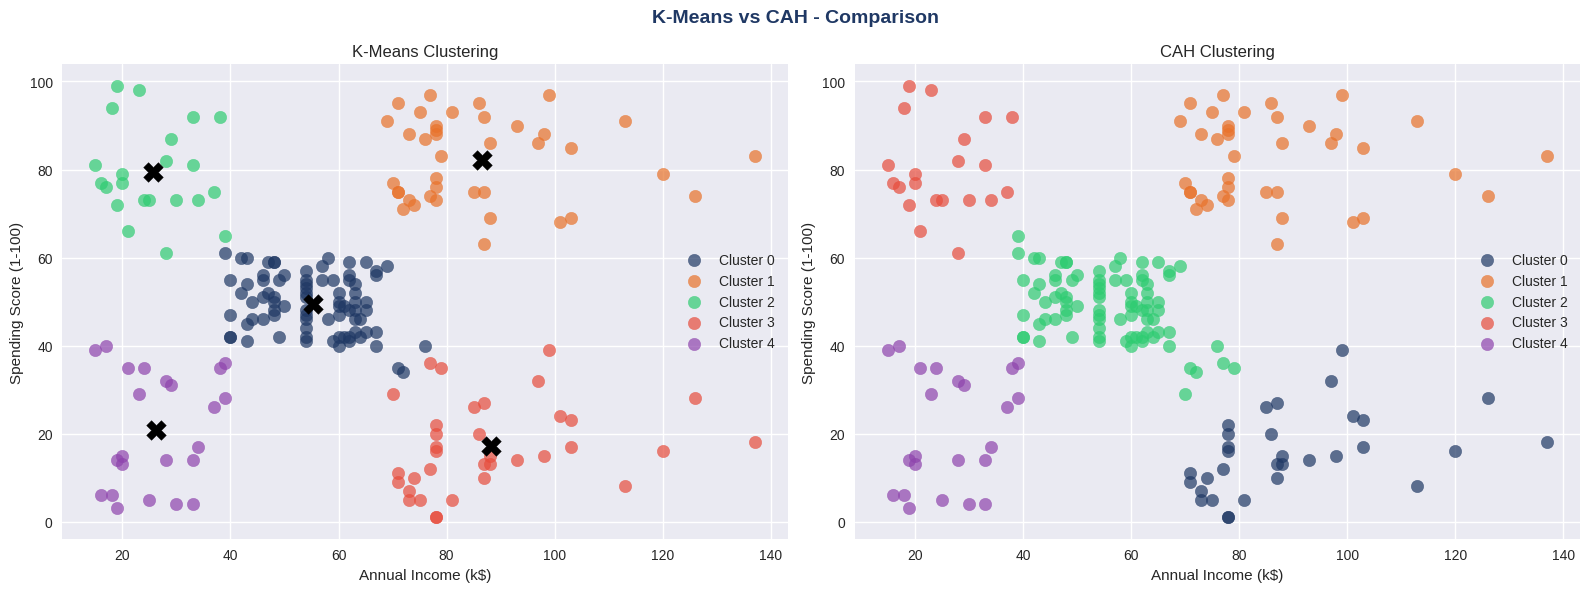

Both K-Means and CAH identify the same 5 customer segments with nearly identical profiles.
This convergence across two independent algorithms strongly validates the cluster structure found in the data.
The segmentation is robust and reliable enough to support business decisions.



In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for i in range(5):
    data = customers[customers['Cluster'] == i]
    axes[0].scatter(
        data['Annual Income (k$)'],
        data['Spending Score (1-100)'],
        color=colors[i],
        label=f'Cluster {i}',
        alpha=0.7, s=80)

centroids = scaler.inverse_transform(
    kmeans.cluster_centers_)
axes[0].scatter(centroids[:, 0],
                centroids[:, 1],
                color='black', marker='X',
                s=200, zorder=5)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend()

# CAH
for i in range(5):
    data = customers[customers['Cluster_CAH'] == i]
    axes[1].scatter(
        data['Annual Income (k$)'],
        data['Spending Score (1-100)'],
        color=colors[i],
        label=f'Cluster {i}',
        alpha=0.7, s=80)

axes[1].set_title('CAH Clustering')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend()

plt.suptitle('K-Means vs CAH - Comparison',
             fontsize=14, fontweight='bold',
             color='#1F3864')
plt.tight_layout()
plt.savefig('kmeans_vs_cah.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("""Both K-Means and CAH identify the same 5 customer segments with nearly identical profiles.
This convergence across two independent algorithms strongly validates the cluster structure found in the data.
The segmentation is robust and reliable enough to support business decisions.
""")

## 🌐 3D Visualization
### Age, Income and Spending Score

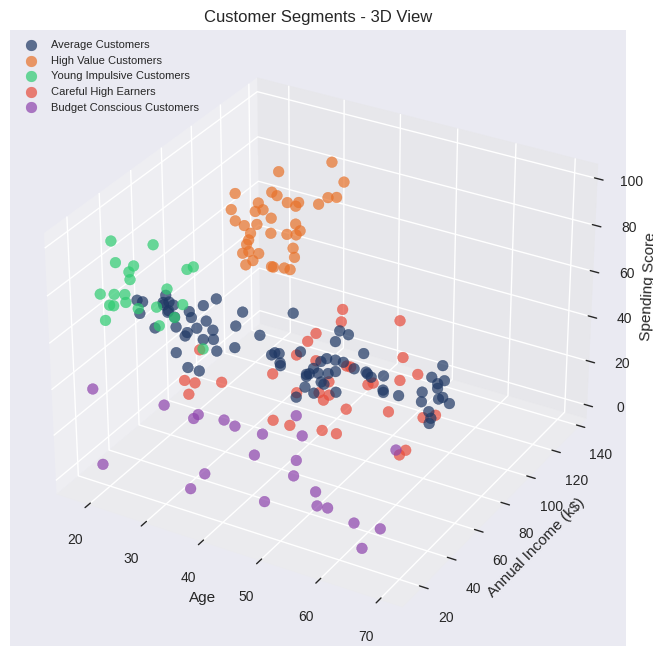

In [24]:
from mpl_toolkits.mplot3d import Axes3D

colors = ['#1F3864', '#E8722A', '#2ECC71',
          '#E74C3C', '#8E44AD']

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(5):
    data = customers[customers['Cluster'] == i]
    ax.scatter(data['Age'],
               data['Annual Income (k$)'],
               data['Spending Score (1-100)'],
               color=colors[i],
               label=cluster_names[i],
               alpha=0.7, s=60)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score')
ax.set_title('Customer Segments - 3D View')
ax.legend(loc='upper left', fontsize=8)

plt.savefig('clusters_3d.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 💡 Key Business Insights and Recommendations

In [28]:
print("=" * 55)
print("CUSTOMER SEGMENTS - BUSINESS INSIGHTS")
print("=" * 55)

print("\n⭐ HIGH VALUE CUSTOMERS (Cluster 1)")
print("-" * 55)
print("39 customers. Average income $86K.")
print("Spending score 82 out of 100.")
print("These are young professionals who earn")
print("well and actually spend it. They are the")
print("most profitable segment by far and the")
print("ones most worth fighting to keep.")
print("Loyalty programs, premium experiences")
print("and early access to new collections")
print("are the right moves here.")

print("\n🛍️ YOUNG IMPULSIVE CUSTOMERS (Cluster 2)")
print("-" * 55)
print("22 customers. Average income $25K.")
print("Spending score 79 out of 100.")
print("They spend heavily despite modest means.")
print("High energy, high engagement - but")
print("the gap between income and spending")
print("is worth watching. Affordable premium")
print("options and installment plans would")
print("suit this segment well.")

print("\n💰 CAREFUL HIGH EARNERS (Cluster 3)")
print("-" * 55)
print("35 customers. Average income $88K.")
print("Spending score just 17 out of 100.")
print("The money is there. The spending is not.")
print("This is the most interesting segment")
print("from a growth perspective - they have")
print("more disposable income than anyone else")
print("but are not being converted.")
print("Quality positioning and exclusive offers")
print("are the way in.")

print("\n👥 AVERAGE CUSTOMERS (Cluster 0)")
print("-" * 55)
print("81 customers - the largest group.")
print("Middle income, middle spending.")
print("Reliable but disengaged. A well-timed")
print("promotion or loyalty incentive could")
print("nudge a meaningful portion of this")
print("segment toward higher spending.")

print("\n💵 BUDGET CONSCIOUS CUSTOMERS (Cluster 4)")
print("-" * 55)
print("23 customers. Average income $26K.")
print("Spending score 21 out of 100.")
print("Low income and cautious with money.")
print("Limited short-term revenue potential.")
print("Entry-level ranges and value deals")
print("are the most realistic approach.")

print("\n" + "=" * 55)
print("BOTTOM LINE")
print("=" * 55)
print("Two segments stand out.")
print("High Value Customers are already spending")
print("and need to be kept engaged and loyal.")
print("Careful High Earners are the real prize -")
print("$88K average income, score of 17.")
print("They are not being reached effectively.")
print("Converting even part of that segment")
print("would move the revenue needle more than")
print("any other action available right now.")
print("=" * 55)

CUSTOMER SEGMENTS - BUSINESS INSIGHTS

⭐ HIGH VALUE CUSTOMERS (Cluster 1)
-------------------------------------------------------
39 customers. Average income $86K.
Spending score 82 out of 100.
These are young professionals who earn
well and actually spend it. They are the
most profitable segment by far and the
ones most worth fighting to keep.
Loyalty programs, premium experiences
and early access to new collections
are the right moves here.

🛍️ YOUNG IMPULSIVE CUSTOMERS (Cluster 2)
-------------------------------------------------------
22 customers. Average income $25K.
Spending score 79 out of 100.
They spend heavily despite modest means.
High energy, high engagement - but
the gap between income and spending
is worth watching. Affordable premium
options and installment plans would
suit this segment well.

💰 CAREFUL HIGH EARNERS (Cluster 3)
-------------------------------------------------------
35 customers. Average income $88K.
Spending score just 17 out of 100.
The money is ther